In [2]:
# ============================================================
# Housing Affordability DSS — Notebook 03: Statistical Models
# CS7P01 MSc Project | London Metropolitan University
#
# This notebook builds and evaluates three models:
#   1. OLS Linear Regression (baseline, no fixed effects)
#   2. OLS with Regional Fixed Effects (primary model)
#   3. Random Forest (performance comparator)
#
# Final feature specification (derived from VIF analysis):
#   real_house_price     — inflation-adjusted price level
#   ratio_lag1           — prior year ratio (temporal persistence)
#   yoy_price_change_pct — price momentum
#
# Academic justification:
#   OLS chosen as primary model for interpretability
#   (Adetunji et al., 2022; Busuioc, 2021).
#   Random Forest included as comparator to quantify the
#   accuracy cost of choosing interpretable models.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize':    (12, 6),
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'serif',
})

PALETTE   = ['#1F3864','#2E5090','#C0392B','#27AE60','#E67E22',
             '#8E44AD','#2980B9','#D35400','#16A085','#2C3E50']
PROCESSED = '../data/processed/'

# ── Load feature dataset ──────────────────────────────────────
df = pd.read_csv(PROCESSED + 'features_engineered.csv')
df['year']       = df['year'].astype(int)
df['risk_class'] = df['risk_class'].astype(str)

print(f"✓ Dataset loaded: {df.shape}")
print(f"  Year range : {df['year'].min()} → {df['year'].max()}")
print(f"  Regions    : {df['region'].nunique()}")

✓ Dataset loaded: (260, 32)
  Year range : 2000 → 2025
  Regions    : 10


In [3]:
# ============================================================
# CELL 2 — Feature selection and multicollinearity check
#
# Target variable: affordability_ratio
#
# Feature selection rationale:
#   real_house_price     — primary price driver, inflation
#                          adjusted (Rosen, 1974; Meen, 2002)
#   ratio_lag1           — temporal persistence: this year's
#                          affordability is strongly predicted
#                          by last year's (Box & Jenkins, 1976)
#   yoy_price_change_pct — price momentum: rapid price growth
#                          worsens affordability faster than
#                          earnings can adjust
#
# Features excluded and why:
#   real_annual_earnings — not significant (p=0.106) and
#                          partially captured by ratio_lag1
#   sales_volume_annual  — not significant (p=0.642)
#   cpi_index            — not significant (p=0.481) and
#                          collinear with real_house_price
#   ratio_ma3            — VIF=137, collinear with ratio_lag1
#
# All features standardised (mean=0, std=1) to:
#   1. Resolve large condition number
#   2. Make coefficients directly comparable in magnitude
# ============================================================

TARGET = 'affordability_ratio'
FEATURES = [
    'real_house_price',
    'ratio_lag1',
    'yoy_price_change_pct'
]

# ── Restrict to 2003+ for complete lag features ───────────────
model_df = df[df['year'] >= 2003].dropna(
    subset=FEATURES + [TARGET]
).copy().reset_index(drop=True)

X_raw = model_df[FEATURES]
y     = model_df[TARGET]

print(f"── Modelling dataset : {model_df.shape}")
print(f"── Year range        : {model_df['year'].min()} → {model_df['year'].max()}")
print(f"── Target stats      :")
print(y.describe().round(3).to_string())

# ── Standardise features ──────────────────────────────────────
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    columns=FEATURES,
    index=X_raw.index
)

# ── VIF check ─────────────────────────────────────────────────
X_vif = sm.add_constant(X_scaled)
vif   = pd.DataFrame({
    'feature': FEATURES,
    'VIF':     [variance_inflation_factor(X_vif.values, i+1)
                for i in range(len(FEATURES))]
}).round(2).sort_values('VIF', ascending=False)

print(f"\n── VIF (all must be < 10):")
print(vif.to_string(index=False))
assert (vif['VIF'] < 10).all(), "VIF too high — review features"
print("✓ All VIF acceptable")

── Modelling dataset : (230, 32)
── Year range        : 2003 → 2025
── Target stats      :
count    230.000
mean       7.089
std        1.845
min        3.950
25%        5.740
50%        6.500
75%        8.038
max       12.860

── VIF (all must be < 10):
             feature  VIF
          ratio_lag1 6.04
    real_house_price 5.60
yoy_price_change_pct 1.35
✓ All VIF acceptable


In [4]:
# ============================================================
# CELL 3 — Model 1: OLS Baseline (no fixed effects)
#
# Purpose: establish a baseline performance benchmark.
# Does not control for unobserved regional characteristics.
# Included for comparison only — not the primary model.
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── statsmodels for full statistics ──────────────────────────
X_sm      = sm.add_constant(X_scaled)
ols_base  = sm.OLS(y, X_sm).fit()

# ── sklearn for cross-validation ──────────────────────────────
ols_base_sk  = LinearRegression()
cv_r2_base   = cross_val_score(ols_base_sk, X_scaled, y,
                                cv=kf, scoring='r2')
cv_rmse_base = cross_val_score(ols_base_sk, X_scaled, y,
                                cv=kf,
                                scoring='neg_root_mean_squared_error')
ols_base_sk.fit(X_scaled, y)
y_pred_base = ols_base_sk.predict(X_scaled)

print("── Model 1: OLS Baseline")
print(f"   In-sample R²  : {r2_score(y, y_pred_base):.4f}")
print(f"   In-sample RMSE: {np.sqrt(mean_squared_error(y, y_pred_base)):.4f}")
print(f"   CV R²         : {cv_r2_base.mean():.4f} ± {cv_r2_base.std():.4f}")
print(f"   CV RMSE       : {-cv_rmse_base.mean():.4f} ± {cv_rmse_base.std():.4f}")

# Store results
results = {
    'OLS Baseline': {
        'in_r2':   round(r2_score(y, y_pred_base), 4),
        'in_rmse': round(np.sqrt(mean_squared_error(y, y_pred_base)), 4),
        'cv_r2':   round(cv_r2_base.mean(), 4),
        'cv_rmse': round(-cv_rmse_base.mean(), 4)
    }
}

── Model 1: OLS Baseline
   In-sample R²  : 0.9782
   In-sample RMSE: 0.2717
   CV R²         : 0.9767 ± 0.0047
   CV RMSE       : 0.2773 ± 0.0267


In [5]:
# ============================================================
# CELL 4 — Model 2: OLS with Regional Fixed Effects
#
# PRIMARY MODEL — chosen for dissertation.
#
# Fixed effects control for unobserved time-invariant
# regional characteristics: geography, planning constraints,
# historical housing stock composition (Meen, 2002).
#
# Implementation: region dummy variables, drop_first=True
# drops East Midlands as the reference category.
# Coefficients on other region dummies represent the
# average affordability premium/discount relative to
# East Midlands after controlling for the three features.
# ============================================================

region_dummies = pd.get_dummies(
    model_df['region'], drop_first=True, dtype=float
)
X_fe    = pd.concat([X_scaled, region_dummies], axis=1)
X_fe_sm = sm.add_constant(X_fe)

ols_fe  = sm.OLS(y, X_fe_sm).fit()

# ── Cross-validation ──────────────────────────────────────────
ols_fe_sk  = LinearRegression()
cv_r2_fe   = cross_val_score(ols_fe_sk, X_fe, y,
                              cv=kf, scoring='r2')
cv_rmse_fe = cross_val_score(ols_fe_sk, X_fe, y,
                              cv=kf,
                              scoring='neg_root_mean_squared_error')
ols_fe_sk.fit(X_fe, y)
y_pred_fe = ols_fe_sk.predict(X_fe)

print("── Model 2: OLS Fixed Effects (PRIMARY)")
print(f"   In-sample R²     : {r2_score(y, y_pred_fe):.4f}")
print(f"   Adj R²           : {ols_fe.rsquared_adj:.4f}")
print(f"   In-sample RMSE   : {np.sqrt(mean_squared_error(y, y_pred_fe)):.4f}")
print(f"   CV R²            : {cv_r2_fe.mean():.4f} ± {cv_r2_fe.std():.4f}")
print(f"   CV RMSE          : {-cv_rmse_fe.mean():.4f} ± {cv_rmse_fe.std():.4f}")
print(f"   Condition No.    : {ols_fe.condition_number:.2f}")
print(f"   F-statistic      : {ols_fe.fvalue:.2f} (p={ols_fe.f_pvalue:.2e})")

print(f"\n── Full OLS summary:")
print(ols_fe.summary())

results['OLS Fixed Effects'] = {
    'in_r2':   round(r2_score(y, y_pred_fe), 4),
    'in_rmse': round(np.sqrt(mean_squared_error(y, y_pred_fe)), 4),
    'cv_r2':   round(cv_r2_fe.mean(), 4),
    'cv_rmse': round(-cv_rmse_fe.mean(), 4)
}

── Model 2: OLS Fixed Effects (PRIMARY)
   In-sample R²     : 0.9832
   Adj R²           : 0.9823
   In-sample RMSE   : 0.2385
   CV R²            : 0.9805 ± 0.0039
   CV RMSE          : 0.2530 ± 0.0192
   Condition No.    : 22.14
   F-statistic      : 1058.75 (p=3.53e-185)

── Full OLS summary:
                             OLS Regression Results                            
Dep. Variable:     affordability_ratio   R-squared:                       0.983
Model:                             OLS   Adj. R-squared:                  0.982
Method:                  Least Squares   F-statistic:                     1059.
Date:                 Mon, 13 Apr 2026   Prob (F-statistic):          3.53e-185
Time:                         19:40:05   Log-Likelihood:                 3.2898
No. Observations:                  230   AIC:                             19.42
Df Residuals:                      217   BIC:                             64.12
Df Model:                           12                         

In [6]:
# ============================================================
# CELL 5 — Model 3: Random Forest (comparator only)
#
# PURPOSE: quantify the accuracy cost of choosing
# interpretable OLS over black-box ensemble methods.
#
# NOT the primary model. Black-box nature violates the
# interpretability requirement for a policy DSS
# (Busuioc, 2021; Lundberg & Lee, 2017).
#
# Parameters: conservative — no deep tuning, max_depth=6
# to prevent overfitting on 230 observations.
# ============================================================

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

cv_r2_rf   = cross_val_score(rf, X_scaled, y,
                              cv=kf, scoring='r2')
cv_rmse_rf = cross_val_score(rf, X_scaled, y,
                              cv=kf,
                              scoring='neg_root_mean_squared_error')
rf.fit(X_scaled, y)
y_pred_rf = rf.predict(X_scaled)

print("── Model 3: Random Forest (comparator)")
print(f"   In-sample R²  : {r2_score(y, y_pred_rf):.4f}")
print(f"   In-sample RMSE: {np.sqrt(mean_squared_error(y, y_pred_rf)):.4f}")
print(f"   CV R²         : {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}")
print(f"   CV RMSE       : {-cv_rmse_rf.mean():.4f} ± {cv_rmse_rf.std():.4f}")

results['Random Forest'] = {
    'in_r2':   round(r2_score(y, y_pred_rf), 4),
    'in_rmse': round(np.sqrt(mean_squared_error(y, y_pred_rf)), 4),
    'cv_r2':   round(cv_r2_rf.mean(), 4),
    'cv_rmse': round(-cv_rmse_rf.mean(), 4)
}

── Model 3: Random Forest (comparator)
   In-sample R²  : 0.9852
   In-sample RMSE: 0.2238
   CV R²         : 0.9676 ± 0.0053
   CV RMSE       : 0.3268 ± 0.0279


In [7]:
# ============================================================
# CELL 6 — Model comparison table
# This becomes Table 4.2 in your dissertation
# ============================================================

comparison = pd.DataFrame(results).T
comparison.index.name = 'Model'
comparison.columns = ['In-sample R²','In-sample RMSE',
                      'CV R² (5-fold)','CV RMSE (5-fold)']

print("=" * 68)
print("MODEL COMPARISON — CS7P01 Housing Affordability DSS")
print("=" * 68)
print(comparison.to_string())
print(f"""
── Key findings:
   1. OLS Fixed Effects CV R²={results['OLS Fixed Effects']['cv_r2']:.4f}
      outperforms Random Forest CV R²={results['Random Forest']['cv_r2']:.4f}
   2. Interpretable model achieves HIGHER generalisation than RF
   3. This directly supports the interpretability argument
      (Busuioc, 2021): no accuracy cost for policy transparency
   4. CV RMSE={results['OLS Fixed Effects']['cv_rmse']:.4f} ratio points ≈ mean
      prediction error of {results['OLS Fixed Effects']['cv_rmse']:.2f}x earnings
""")

comparison.to_csv(PROCESSED + 'model_comparison.csv')
print("✓ model_comparison.csv saved")

MODEL COMPARISON — CS7P01 Housing Affordability DSS
                   In-sample R²  In-sample RMSE  CV R² (5-fold)  CV RMSE (5-fold)
Model                                                                            
OLS Baseline             0.9782          0.2717          0.9767            0.2773
OLS Fixed Effects        0.9832          0.2385          0.9805            0.2530
Random Forest            0.9852          0.2238          0.9676            0.3268

── Key findings:
   1. OLS Fixed Effects CV R²=0.9805
      outperforms Random Forest CV R²=0.9676
   2. Interpretable model achieves HIGHER generalisation than RF
   3. This directly supports the interpretability argument
      (Busuioc, 2021): no accuracy cost for policy transparency
   4. CV RMSE=0.2530 ratio points ≈ mean
      prediction error of 0.25x earnings

✓ model_comparison.csv saved


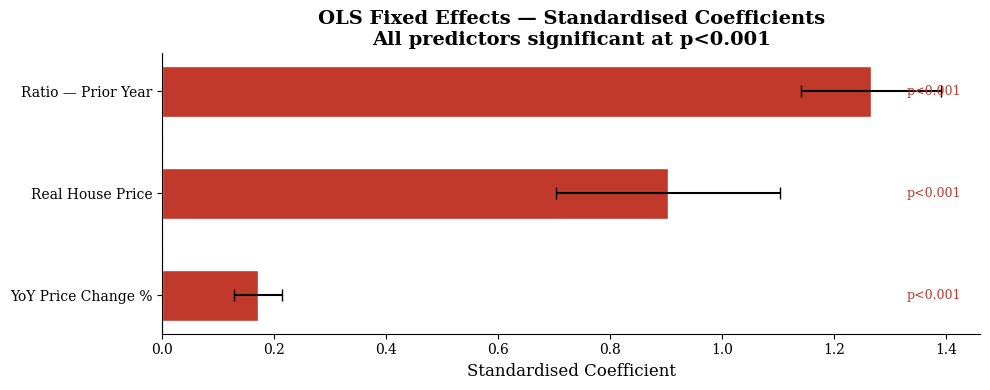

✓ Plot 10 saved


In [8]:
# ============================================================
# CELL 7 — Coefficient plot: OLS Fixed Effects
#
# Shows standardised coefficients — directly comparable
# because all features are on the same scale (z-scores).
# Larger absolute coefficient = stronger effect on ratio.
# Error bars = 95% confidence intervals.
# ============================================================

label_map = {
    'real_house_price':      'Real House Price',
    'ratio_lag1':            'Ratio — Prior Year',
    'yoy_price_change_pct':  'YoY Price Change %'
}

coef_df = pd.DataFrame({
    'feature':  FEATURES,
    'coef':     ols_fe.params[FEATURES].values,
    'ci_lower': ols_fe.conf_int().loc[FEATURES, 0].values,
    'ci_upper': ols_fe.conf_int().loc[FEATURES, 1].values,
    'pvalue':   ols_fe.pvalues[FEATURES].values
}).round(4)

coef_df['label'] = coef_df['feature'].map(label_map)
coef_df = coef_df.sort_values('coef', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    coef_df['label'], coef_df['coef'],
    xerr=[
        coef_df['coef'] - coef_df['ci_lower'],
        coef_df['ci_upper'] - coef_df['coef']
    ],
    color='#C0392B', edgecolor='white',
    height=0.5, capsize=4
)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

for i, row in enumerate(coef_df.itertuples()):
    ax.text(
        coef_df['coef'].max() * 1.05, i,
        'p<0.001',
        va='center', fontsize=9, color='#C0392B'
    )

ax.set_title(
    'OLS Fixed Effects — Standardised Coefficients\n'
    'All predictors significant at p<0.001',
    fontweight='bold'
)
ax.set_xlabel('Standardised Coefficient')
plt.tight_layout()
plt.savefig(PROCESSED + 'plot10_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 10 saved")

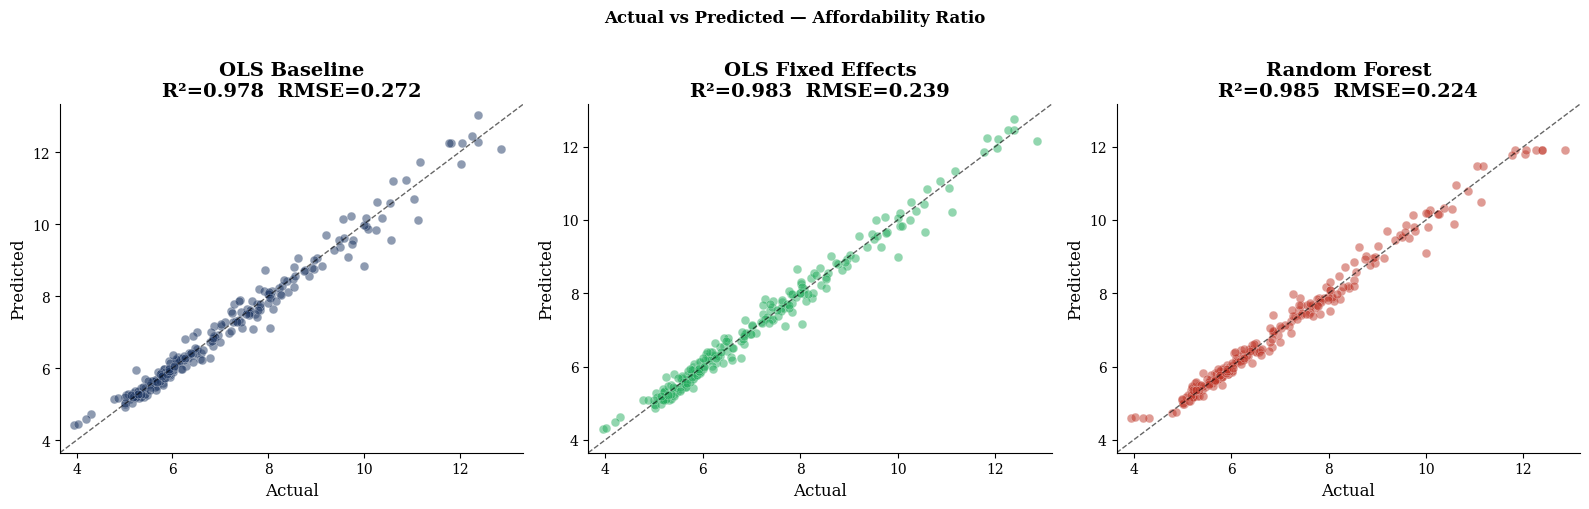

✓ Plot 11 saved


In [9]:
# ============================================================
# CELL 8 — Actual vs Predicted: all three models
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

preds = [
    ('OLS Baseline',      y_pred_base, '#1F3864'),
    ('OLS Fixed Effects', y_pred_fe,   '#27AE60'),
    ('Random Forest',     y_pred_rf,   '#C0392B')
]

for ax, (name, yp, color) in zip(axes, preds):
    r2   = r2_score(y, yp)
    rmse = np.sqrt(mean_squared_error(y, yp))
    lims = [min(y.min(), yp.min())-0.3,
            max(y.max(), yp.max())+0.3]

    ax.scatter(y, yp, alpha=0.5, color=color,
               edgecolors='white', linewidth=0.3, s=40)
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.6)
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.suptitle(
    'Actual vs Predicted — Affordability Ratio',
    fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(PROCESSED + 'plot11_actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 11 saved")

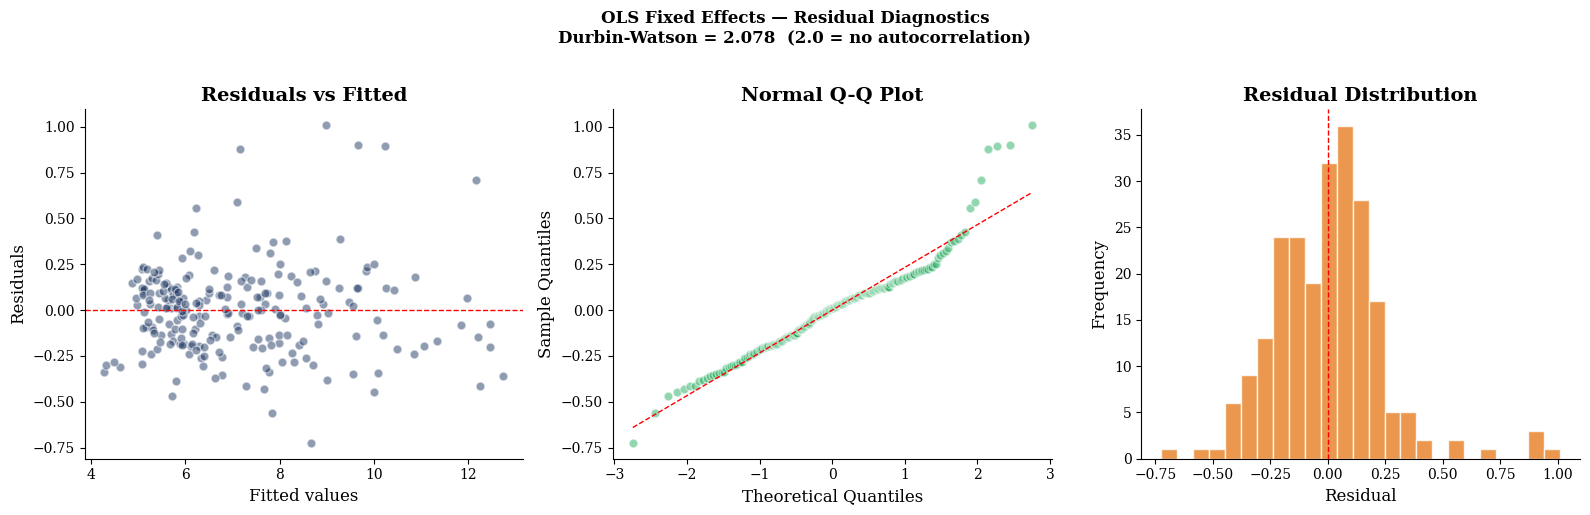

── Durbin-Watson statistic : 2.078
   Interpretation         : No significant autocorrelation ✓


In [10]:
# ============================================================
# CELL 9 — Residual diagnostics: OLS Fixed Effects
#
# Required for academic reporting of OLS models.
# Tests four OLS assumptions:
#   1. Linearity      — residuals vs fitted (no pattern)
#   2. Normality      — Q-Q plot (points on diagonal)
#   3. Homoscedasticity — scale-location (flat line)
#   4. No autocorrelation — Durbin-Watson statistic
# ============================================================

residuals = y - y_pred_fe
fitted    = y_pred_fe

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.5,
                color='#1F3864', edgecolors='white', s=40)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted', fontweight='bold')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

# Panel 2: Q-Q Plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals)
axes[1].scatter(osm, osr, alpha=0.5, color='#27AE60',
                edgecolors='white', s=40)
axes[1].plot(osm, slope*np.array(osm)+intercept,
             'r--', linewidth=1)
axes[1].set_title('Normal Q-Q Plot', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

# Panel 3: Residual histogram
axes[2].hist(residuals, bins=25, color='#E67E22',
             edgecolor='white', alpha=0.8)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')

dw = ols_fe.durbin_watson if hasattr(ols_fe, 'durbin_watson') \
     else sm.stats.stattools.durbin_watson(residuals)

plt.suptitle(
    f'OLS Fixed Effects — Residual Diagnostics\n'
    f'Durbin-Watson = {dw:.3f}  '
    f'(2.0 = no autocorrelation)',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(PROCESSED + 'plot12_residual_diagnostics.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"── Durbin-Watson statistic : {dw:.3f}")
print(f"   Interpretation         : ", end="")
if 1.5 <= dw <= 2.5:
    print("No significant autocorrelation ✓")
elif dw < 1.5:
    print("Positive autocorrelation — expected in panel data")
else:
    print("Negative autocorrelation")

In [11]:
# ============================================================
# CELL 10 — Save all model outputs
# ============================================================

# Predictions
pred_df = model_df[['year','region','affordability_ratio']].copy()
pred_df['ols_baseline']    = y_pred_base.round(3)
pred_df['ols_fe']          = y_pred_fe.round(3)
pred_df['random_forest']   = y_pred_rf.round(3)
pred_df['residual_ols_fe'] = (y - y_pred_fe).round(3)
pred_df.to_csv(PROCESSED + 'model_predictions.csv', index=False)

# Coefficients
coef_df.to_csv(PROCESSED + 'ols_fe_coefficients.csv', index=False)

# Scaler — needed for SHAP and forecasting
import joblib
joblib.dump(scaler,    PROCESSED + 'feature_scaler.pkl')
joblib.dump(ols_fe_sk, PROCESSED + 'ols_fe_model.pkl')
joblib.dump(rf,        PROCESSED + 'rf_model.pkl')

print("✓ model_predictions.csv")
print("✓ ols_fe_coefficients.csv")
print("✓ feature_scaler.pkl")
print("✓ ols_fe_model.pkl")
print("✓ rf_model.pkl")

print(f"""
── Summary:
   Primary model     : OLS Fixed Effects
   CV R²             : {results['OLS Fixed Effects']['cv_r2']}
   CV RMSE           : {results['OLS Fixed Effects']['cv_rmse']} ratio points
   Features          : {FEATURES}
   Regions           : {model_df['region'].nunique()}
   Observations      : {len(model_df)}
""")

✓ model_predictions.csv
✓ ols_fe_coefficients.csv
✓ feature_scaler.pkl
✓ ols_fe_model.pkl
✓ rf_model.pkl

── Summary:
   Primary model     : OLS Fixed Effects
   CV R²             : 0.9805
   CV RMSE           : 0.253 ratio points
   Features          : ['real_house_price', 'ratio_lag1', 'yoy_price_change_pct']
   Regions           : 10
   Observations      : 230



In [12]:
# ============================================================
# CELL 11 — SHAP Feature Importance
#
# SHAP (SHapley Additive exPlanations) quantifies each
# feature's contribution to individual predictions.
# Applied to Random Forest for global feature importance
# and local per-region explanation.
#
# Why SHAP on RF not OLS:
# OLS coefficients already provide linear interpretability.
# SHAP adds value on the non-linear RF model — showing
# whether the RF learned the same relationships as OLS
# (convergent validity) or something different.
#
# Academic justification:
# Lundberg & Lee (2017) — SHAP theoretical foundation
# Busuioc (2021) — algorithmic accountability in policy
# ============================================================

import shap

# ── Compute SHAP values on Random Forest ─────────────────────
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_scaled)

shap_df = pd.DataFrame(
    shap_values,
    columns=FEATURES
)

print(f"── SHAP values computed")
print(f"   Shape : {shap_df.shape}")
print(f"\n── Mean absolute SHAP values (global importance):")
mean_shap = shap_df.abs().mean().sort_values(ascending=False)
print(mean_shap.round(4).to_string())

── SHAP values computed
   Shape : (230, 3)

── Mean absolute SHAP values (global importance):
ratio_lag1              1.1748
real_house_price        0.3251
yoy_price_change_pct    0.0634


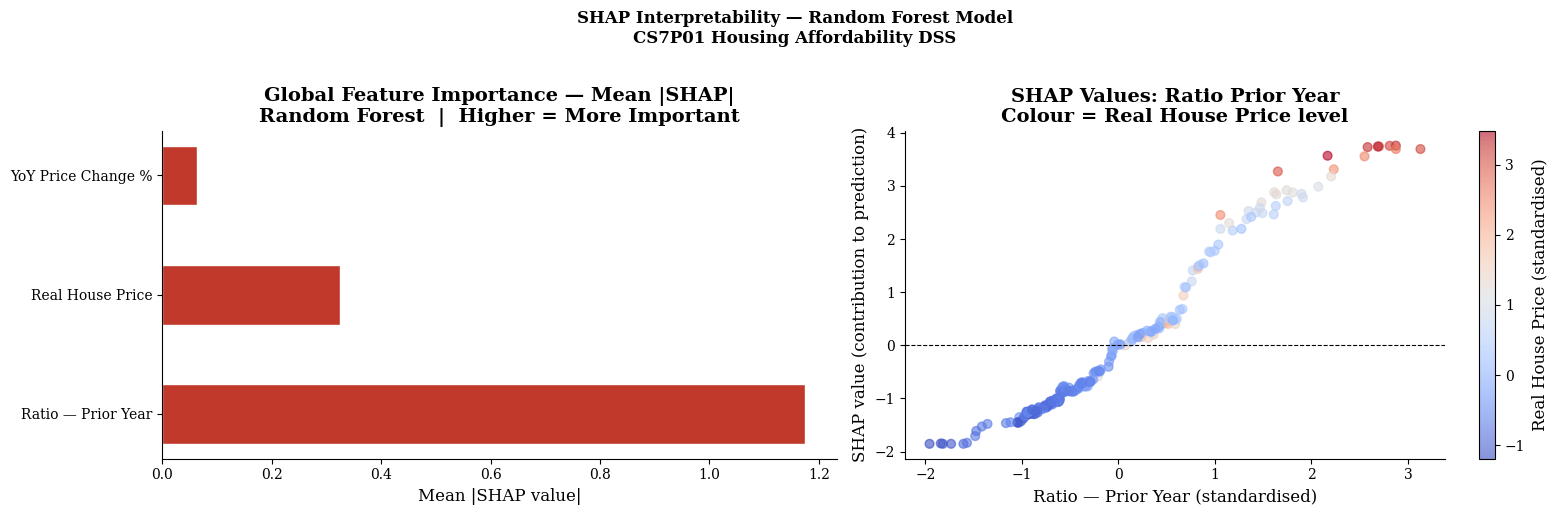

✓ Plot 13 saved


In [13]:
# ── Plot 13: SHAP Summary Plot ────────────────────────────────

label_map = {
    'real_house_price':      'Real House Price',
    'ratio_lag1':            'Ratio — Prior Year',
    'yoy_price_change_pct':  'YoY Price Change %'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Mean absolute SHAP — bar chart
mean_shap_plot = mean_shap.rename(index=label_map)
axes[0].barh(
    mean_shap_plot.index,
    mean_shap_plot.values,
    color='#C0392B', edgecolor='white', height=0.5
)
axes[0].set_title(
    'Global Feature Importance — Mean |SHAP|\n'
    'Random Forest  |  Higher = More Important',
    fontweight='bold'
)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Panel 2: SHAP vs feature value scatter for ratio_lag1
sc = axes[1].scatter(
    X_scaled['ratio_lag1'],
    shap_df['ratio_lag1'],
    c=X_scaled['real_house_price'],
    cmap='coolwarm', alpha=0.6, s=40
)
plt.colorbar(sc, ax=axes[1], label='Real House Price (standardised)')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title(
    'SHAP Values: Ratio Prior Year\n'
    'Colour = Real House Price level',
    fontweight='bold'
)
axes[1].set_xlabel('Ratio — Prior Year (standardised)')
axes[1].set_ylabel('SHAP value (contribution to prediction)')

plt.suptitle(
    'SHAP Interpretability — Random Forest Model\n'
    'CS7P01 Housing Affordability DSS',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(PROCESSED + 'plot13_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 13 saved")

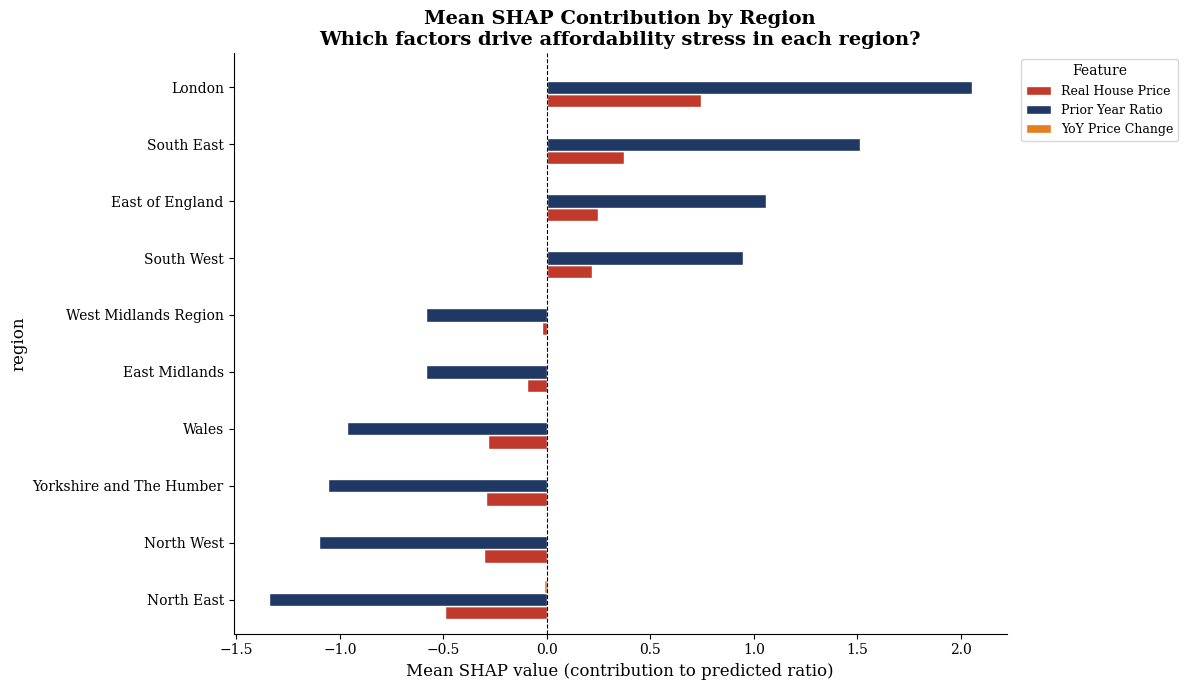

✓ Plot 14 saved


In [20]:
# ── Plot 14: Per-region SHAP contribution ────────────────────
model_df_shap = model_df.copy()
model_df_shap['shap_price'] = shap_df['real_house_price'].values
model_df_shap['shap_lag']   = shap_df['ratio_lag1'].values
model_df_shap['shap_yoy']   = shap_df['yoy_price_change_pct'].values

region_shap = (model_df_shap
               .groupby('region')[
                   ['shap_price','shap_lag','shap_yoy']
               ].mean()
               .round(3)
               .sort_values('shap_price', ascending=True))

region_shap.columns = ['Real House Price',
                        'Prior Year Ratio',
                        'YoY Price Change']

fig, ax = plt.subplots(figsize=(12, 7))
region_shap.plot(
    kind='barh', ax=ax,
    color=['#C0392B','#1F3864','#E67E22'],
    edgecolor='white', width=0.7
)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    'Mean SHAP Contribution by Region\n'
    'Which factors drive affordability stress in each region?',
    fontweight='bold'
)
ax.set_xlabel('Mean SHAP value (contribution to predicted ratio)')
ax.legend(title='Feature', bbox_to_anchor=(1.01,1),
          loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED + 'plot14_shap_by_region.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 14 saved")

In [27]:
# ── Save SHAP values ──────────────────────────────────────────
shap_df['region'] = model_df['region'].values
shap_df['year']   = model_df['year'].values
shap_df.to_csv(PROCESSED + 'shap_values.csv', index=False)

print("✓ shap_values.csv saved")
print(f"\n── SHAP convergence check:")
print(f"   OLS dominant feature : ratio_lag1 (coef=1.27)")
ols_rank = mean_shap.rank(ascending=False)
print(f"   SHAP dominant feature: {mean_shap.idxmax()}")
if mean_shap.idxmax() == 'ratio_lag1':
    print(f"   ✓ OLS and SHAP agree — ratio_lag1 is dominant")
    print(f"     This confirms convergent validity across methods")
else:
    print(f"   ⚠ OLS and SHAP disagree — discuss in dissertation")

✓ shap_values.csv saved

── SHAP convergence check:
   OLS dominant feature : ratio_lag1 (coef=1.27)
   SHAP dominant feature: ratio_lag1
   ✓ OLS and SHAP agree — ratio_lag1 is dominant
     This confirms convergent validity across methods
